In [1]:
# Install the necessary libraries
!pip install opencv-contrib-python numpy

📁 Upload an image to detect handwritten boxes:


Saving WhatsApp Image 2026-04-13 at 11.22.34 PM.jpeg to WhatsApp Image 2026-04-13 at 11.22.34 PM (1).jpeg

🔍 Processing: WhatsApp Image 2026-04-13 at 11.22.34 PM (1).jpeg

  Detected 2 box(es)  |  WhatsApp Image 2026-04-13 at 11.22.34 PM (1).jpeg
  Box 1: pos=(120, 241)  size=423×91  vertices=4  solidity=0.948  conf=1.0
  Box 2: pos=(133, 769)  size=749×120  vertices=6  solidity=0.617  conf=0.9

📌 Annotated image:


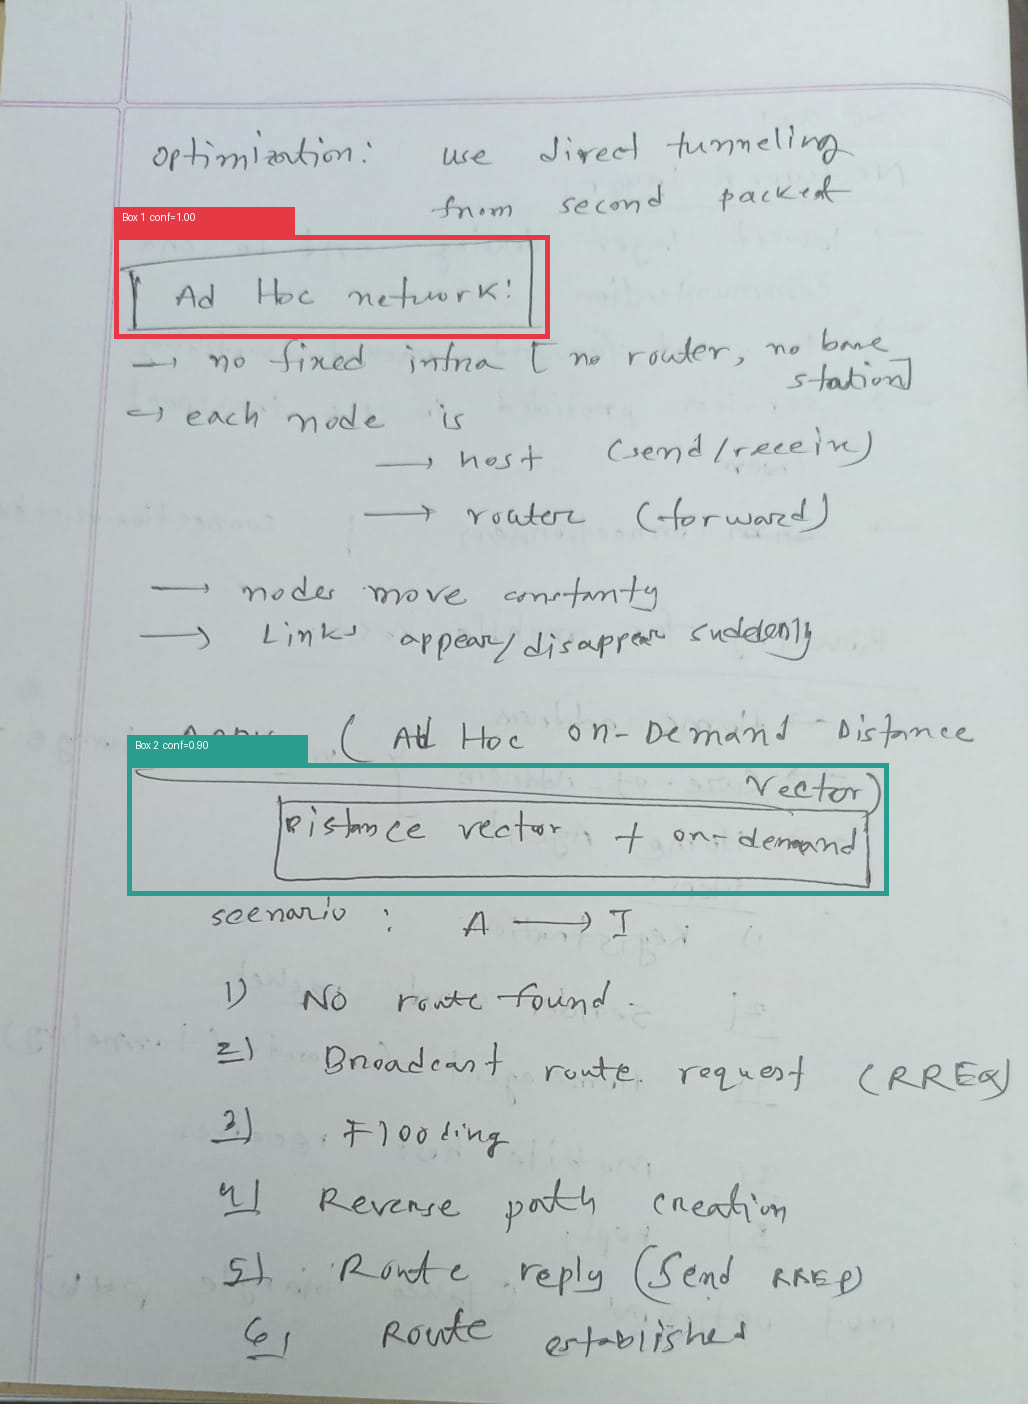


✂️  Cropped boxes:
  Box 1:


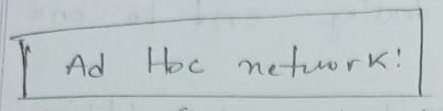

  Box 2:


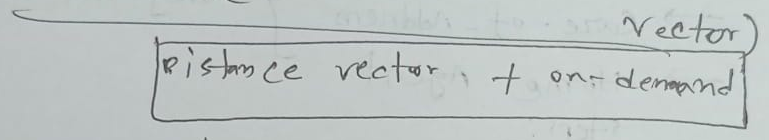


✅ Done! JSON summary:
[
  {
    "bbox": {
      "x": 120,
      "y": 241,
      "w": 423,
      "h": 91
    },
    "area": 32329.5,
    "num_vertices": 4,
    "solidity": 0.948,
    "confidence": 1.0,
    "source": "binary",
    "id": 1
  },
  {
    "bbox": {
      "x": 133,
      "y": 769,
      "w": 749,
      "h": 120
    },
    "area": 48034.0,
    "num_vertices": 6,
    "solidity": 0.617,
    "confidence": 0.9,
    "source": "binary",
    "id": 2
  }
]


In [6]:
"""
Handwritten Box Detector – Google Colab Version
================================================
Detects hand-drawn rectangular boxes, crops each one, and saves them as
individual images.

Usage (in a Colab cell):
  Run all cells. You'll be prompted to upload an image.
"""

import cv2
import numpy as np
from PIL import Image, ImageDraw
from google.colab import files
from IPython.display import display, Image as IPImage
import json
import os
import io

COLORS = [
    (230, 57,  70),   # red
    (42,  157, 143),  # teal
    (233, 196, 106),  # amber
    (38,  70,  83),   # dark blue
    (244, 162, 97),   # orange
]


def detect_handwritten_boxes(pil_image):
    img_rgb = np.array(pil_image.convert("RGB"))
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    img_h, img_w = img_bgr.shape[:2]
    image_area = img_h * img_w

    # ── FIX 1: Detect the actual box COLOR via HSV instead of grayscale ──────
    # This handles any distinctly colored box (green, red, blue, etc.)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Build a combined mask for common box colors
    masks = []

    # Green
    masks.append(cv2.inRange(hsv, np.array([35, 40, 40]), np.array([90, 255, 255])))
    # Red (wraps around in HSV — needs two ranges)
    masks.append(cv2.inRange(hsv, np.array([0,  50, 50]), np.array([15, 255, 255])))
    masks.append(cv2.inRange(hsv, np.array([165,50, 50]), np.array([180,255, 255])))
    # Blue
    masks.append(cv2.inRange(hsv, np.array([100,50, 50]), np.array([135,255, 255])))
    # Cyan / teal
    masks.append(cv2.inRange(hsv, np.array([85, 50, 50]), np.array([100,255, 255])))

    color_mask = masks[0]
    for m in masks[1:]:
        color_mask = cv2.bitwise_or(color_mask, m)

    # Also try dark/black ink on white paper (original approach — fallback)
    gray   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=25, C=10,
    )

    # Dilate both masks to close line gaps
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    color_dilated  = cv2.dilate(color_mask, kernel, iterations=2)
    binary_dilated = cv2.dilate(binary,     kernel, iterations=1)

    results = []
    for mask_name, mask in [("color", color_dilated), ("binary", binary_dilated)]:
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < image_area * 0.003 or area > image_area * 0.65:
                continue

            perimeter = cv2.arcLength(cnt, True)
            if perimeter < 80:
                continue

            hull      = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            if hull_area < 1:
                continue

            solidity = area / hull_area
            approx   = cv2.approxPolyDP(cnt, 0.03 * perimeter, True)
            nv       = len(approx)
            x, y, bw, bh = cv2.boundingRect(approx)
            aspect   = max(bw, bh) / (min(bw, bh) + 1e-5)

            # ── FIX 2: Don't use solidity as primary filter for text-filled boxes ──
            # Instead use the BOUNDING RECT fill ratio (extent vs hull)
            # A rectangle outline (even with text inside) has a well-shaped
            # bounding box and a low but consistent aspect ratio.
            if mask_name == "color":
                # For colored boxes: solidity is low because the outline is thin
                # Use hull convexity and shape instead
                if nv < 4 or nv > 12:
                    continue
                if aspect > 8:
                    continue
                # Colored box outlines: area will be small (just the line pixels)
                # so we skip the extent check and use hull area as proxy
                hull_extent = hull_area / (bw * bh + 1e-5)
                if hull_extent < 0.50:   # hull should cover most of bounding rect
                    continue
            else:
                # For dark ink boxes: keep stricter filters but relax solidity
                if solidity < 0.50:      # was 0.85 — relaxed for text-containing boxes
                    continue
                if nv < 4 or nv > 10:
                    continue
                if aspect > 8:
                    continue
                extent = area / (bw * bh + 1e-5)
                if extent < 0.20:        # was 0.25 — slightly relaxed
                    continue

            vertex_score   = max(0.0, 1.0 - abs(nv - 4) * 0.10)
            solidity_score = min(solidity / 0.5, 1.0)
            confidence     = vertex_score * 0.5 + solidity_score * 0.5

            results.append({
                "bbox":         {"x": int(x), "y": int(y), "w": int(bw), "h": int(bh)},
                "area":         float(area),
                "num_vertices": nv,
                "solidity":     round(float(solidity), 3),
                "confidence":   round(float(confidence), 3),
                "source":       mask_name,
            })

    # NMS — remove near-duplicates (same box found in both masks)
    results.sort(key=lambda b: (b["confidence"], b["area"]), reverse=True)
    kept = []
    for box in results:
        bx, by, bw2, bh2 = box["bbox"].values()
        skip = False
        for kb in kept:
            kx, ky, kw, kh = kb["bbox"].values()
            ix    = max(0, min(bx + bw2, kx + kw) - max(bx, kx))
            iy    = max(0, min(by + bh2, ky + kh) - max(by, ky))
            inter = ix * iy
            union = bw2 * bh2 + kw * kh - inter
            if union > 0 and inter / union > 0.40:
                skip = True
                break
        if not skip:
            kept.append(box)

    for i, box in enumerate(kept):
        box["id"] = i + 1

    return kept, img_rgb

def annotate_image(img_rgb, boxes):
    """Draw coloured bounding boxes on a copy of the image."""
    pil_img = Image.fromarray(img_rgb)
    draw    = ImageDraw.Draw(pil_img)

    for box in boxes:
        color = COLORS[(box["id"] - 1) % len(COLORS)]
        x, y, bw, bh = box["bbox"].values()
        pad = 6
        draw.rectangle(
            [x - pad, y - pad, x + bw + pad, y + bh + pad],
            outline=color, width=5,
        )
        label = f"  Box {box['id']}  conf={box['confidence']:.2f}  "
        lw    = len(label) * 9
        draw.rectangle([x - pad, y - pad - 28, x - pad + lw, y - pad], fill=color)
        draw.text((x - pad + 4, y - pad - 24), label, fill="white")

    return pil_img


def crop_boxes(img_rgb, boxes, padding=10):
    """
    Crop each detected box from the image.

    Parameters
    ----------
    img_rgb  : np.ndarray  original RGB image
    boxes    : list[dict]  detected box metadata
    padding  : int         extra pixels around each crop

    Returns
    -------
    crops : list[PIL.Image]
    """
    pil_img = Image.fromarray(img_rgb)
    img_w, img_h = pil_img.size
    crops = []

    for box in boxes:
        x, y, bw, bh = box["bbox"].values()
        # Apply padding, clamped to image bounds
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(img_w, x + bw + padding)
        y2 = min(img_h, y + bh + padding)
        crop = pil_img.crop((x1, y1, x2, y2))
        crops.append(crop)

    return crops


def save_and_download(annotated_img, crops, base_name="detected"):
    """Save annotated image + all crops, then trigger Colab downloads."""
    saved_files = []

    # Save annotated overview
    overview_path = f"{base_name}_annotated.png"
    annotated_img.save(overview_path)
    saved_files.append(overview_path)

    # Save individual crops
    for i, crop in enumerate(crops, start=1):
        crop_path = f"{base_name}_box_{i}.png"
        crop.save(crop_path)
        saved_files.append(crop_path)

    print(f"\nSaved {len(saved_files)} file(s). Downloading now...\n")
    for f in saved_files:
        files.download(f)

    return saved_files


# ── MAIN COLAB FLOW ───────────────────────────────────────────────────────────

print("📁 Upload an image to detect handwritten boxes:")
uploaded = files.upload()

for filename, data in uploaded.items():
    print(f"\n🔍 Processing: {filename}")
    base_name = os.path.splitext(filename)[0]

    # Load image from uploaded bytes
    pil_image = Image.open(io.BytesIO(data))

    # Detect boxes
    boxes, img_rgb = detect_handwritten_boxes(pil_image)

    print(f"\n{'='*55}")
    print(f"  Detected {len(boxes)} box(es)  |  {filename}")
    print(f"{'='*55}")
    for box in boxes:
        b = box["bbox"]
        print(
            f"  Box {box['id']}: "
            f"pos=({b['x']}, {b['y']})  "
            f"size={b['w']}×{b['h']}  "
            f"vertices={box['num_vertices']}  "
            f"solidity={box['solidity']}  "
            f"conf={box['confidence']}"
        )

    if not boxes:
        print("  ⚠️  No boxes detected. Try a cleaner image or adjust thresholds.")
        continue

    # Annotate
    annotated = annotate_image(img_rgb, boxes)

    # Show annotated image inline
    print("\n📌 Annotated image:")
    display(annotated)

    # Crop boxes
    crops = crop_boxes(img_rgb, boxes, padding=10)

    # Show each crop inline
    print("\n✂️  Cropped boxes:")
    for i, crop in enumerate(crops, start=1):
        print(f"  Box {i}:")
        display(crop)

    # Save + download all
    # save_and_download(annotated, crops, base_name=base_name)

    print(f"\n✅ Done! JSON summary:\n{json.dumps(boxes, indent=2)}")